In [110]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [117]:
# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = math.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (math.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * math.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = math.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (math.e**((-(rho(x, y))**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength)))
    E_z_rho = amplitude * phase
    return E_z_rho

def electric_field(omega_0, z, wavelength, a_0, x, y, n, t):
    """
    Finds the value for the physical electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
        t (float): the time
    Returns:
        e_field (float): the physical electric field
    """
    beam = gaussian_beam(omega_0, z, wavelength, a_0, x, y, n)
    angular_frequency = (2 * math.pi * (constants.c/n))/(wavelength * (10**-9))
    time_factor = math.e ** (complex(0,1) * angular_frequency * t)
    e_field = beam * time_factor
    e_field = e_field.real
    return e_field

def gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_1, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho_1 (float): a precalculated rho value
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (math.e**((-(rho_1**2)/(omega_z(omega_0, z, wavelength))**2)))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho_1 ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength))))
    E_z_rho = amplitude * phase
    return E_z_rho

def electric_field_rho(omega_0, z, wavelength, a_0, rho, n, t):
    """
    Finds the value for the physical electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho (float): a precalculated rho value
        n (float): the index of refraction of the medium
        t (float): the time
    Returns:
        e_field (float): the physical electric field
    """
    beam = gaussian_beam_rho(omega_0, z, wavelength, a_0, rho, n)
    angular_frequency = (2 * math.pi * (constants.c/n))/(wavelength * (10**-9))
    time_factor = math.e ** (complex(0,1) * angular_frequency * t)
    e_field = beam * time_factor
    e_field = e_field.real
    return e_field

def plot_3d_points(x, y, z, plot_type='scatter'):
    """
    Plots 3D points or lines from three coordinate arrays.

    Parameters:
        x, y, z (array-like): Coordinate arrays of equal length.
        plot_type (str): 'scatter' or 'line'.
    """
    # Convert to NumPy arrays for consistency
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    z = np.array(z, dtype=float)

    # Validate lengths
    if not (len(x) == len(y) == len(z)):
        raise ValueError("x, y, and z must have the same length.")

    # Create 3D figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Choose plot type
    if plot_type == 'scatter':
        ax.scatter(x, y, z, c=z, marker='o', s=50, depthshade=True)
    elif plot_type == 'line':
        ax.plot(x, y, z, color='blue', linewidth=2)
    else:
        raise ValueError("plot_type must be 'scatter' or 'line'.")

    # Label axes
    ax.set_xlabel('Rho')
    ax.set_ylabel('z')
    ax.set_zlabel('Electric Field')

    plt.show()

In [118]:
electric_field_rho(0.001, 1, 523, 1, 0.00, 1, 1)

-0.20044532545302612

What is the radius of the beam nozzle? 0.001
What is the wavelength in nanometres? 5000
What is the refractive index of the material being propagated through? 1
What is the amplitude of the wave at the start? 10
What is the time value? 1


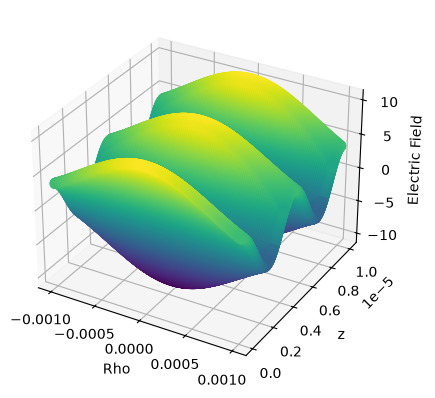

In [116]:
omega_0 = float(input('What is the radius of the beam nozzle?'))
wavelength = int(input('What is the wavelength in nanometres?'))
n = float(input('What is the refractive index of the material being propagated through?'))
a_0 = float(input('What is the amplitude of the wave at the start?'))
time = float(input('What is the time value?'))
z=0.0000001
rho = list(np.linspace(-0.001,0.001,100))
rho_values = []
e_field_values = []
z_values = []

while z <= 0.00001:
    i=0
    while i < len(rho):
        value = rho[i]
        e_field = float(electric_field_rho(omega_0, z, wavelength, a_0, value, n, time))
        e_field_values.append(e_field)
        z_values.append(z)
        rho_values.append(rho[i])
        i+=1
    z+=0.00000001

plot_3d_points(rho_values, z_values, e_field_values, 'scatter')
